# Phase 4 & 5 — DCT Visualization & Statistical Analysis

**Objective:** Transform images from the spatial domain to the frequency domain using the Discrete Cosine Transform (DCT). Phase 4 visualizes the spectral differences between REAL and FAKE images. Phase 5 quantifies those differences statistically, producing measurable evidence that frequency-domain features carry discriminative information invisible to spatial models.

**Why DCT:** GAN-generated images leave characteristic high-frequency artifacts — upsampling patterns, checkerboard noise, and spectral inconsistencies — that are imperceptible to the human eye but mathematically detectable in frequency space.

## Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Configuration & Paths

In [2]:
BASE_PATH   = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"
TRAIN_PATH  = os.path.join(BASE_PATH, "train")
REAL_TRAIN  = os.path.join(TRAIN_PATH, "REAL")
FAKE_TRAIN  = os.path.join(TRAIN_PATH, "FAKE")
RESULT_DIR  = "/kaggle/working/results/frequency_analysis"

os.makedirs(RESULT_DIR, exist_ok=True)

---
# Phase 4 — DCT Visualization

## Load One REAL and One FAKE Sample Image

In [3]:
real_img = cv2.imread(os.path.join(REAL_TRAIN, os.listdir(REAL_TRAIN)[0]))
fake_img = cv2.imread(os.path.join(FAKE_TRAIN, os.listdir(FAKE_TRAIN)[0]))

real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB)
fake_img = cv2.cvtColor(fake_img, cv2.COLOR_BGR2RGB)

real_img = cv2.resize(real_img, (128, 128))
fake_img = cv2.resize(fake_img, (128, 128))

print("Images loaded and resized to 128 x 128.")

Images loaded and resized to 128 x 128.


## Convert to Grayscale and Apply DCT

DCT is applied on the luminance channel only. Color information is less relevant for frequency-artifact detection. Log scaling compresses the wide dynamic range of DCT coefficients so low-energy regions remain visible.

In [4]:
real_gray = cv2.cvtColor(real_img, cv2.COLOR_RGB2GRAY)
fake_gray = cv2.cvtColor(fake_img, cv2.COLOR_RGB2GRAY)

real_dct = cv2.dct(np.float32(real_gray))
fake_dct = cv2.dct(np.float32(fake_gray))

real_dct_vis = np.log(np.abs(real_dct) + 1)
fake_dct_vis = np.log(np.abs(fake_dct) + 1)

print("Real DCT log range :", round(real_dct_vis.min(), 4), "–", round(real_dct_vis.max(), 4))
print("Fake DCT log range :", round(fake_dct_vis.min(), 4), "–", round(fake_dct_vis.max(), 4))

Real DCT log range : 1e-04 – 9.4239
Fake DCT log range : 0.0 – 9.0793


## Plot Spatial Image vs DCT Frequency Spectrum

Low-frequency components (smooth structure) appear in the top-left corner of the DCT spectrum. High-frequency components (edges, noise, synthetic artifacts) appear toward the bottom-right.

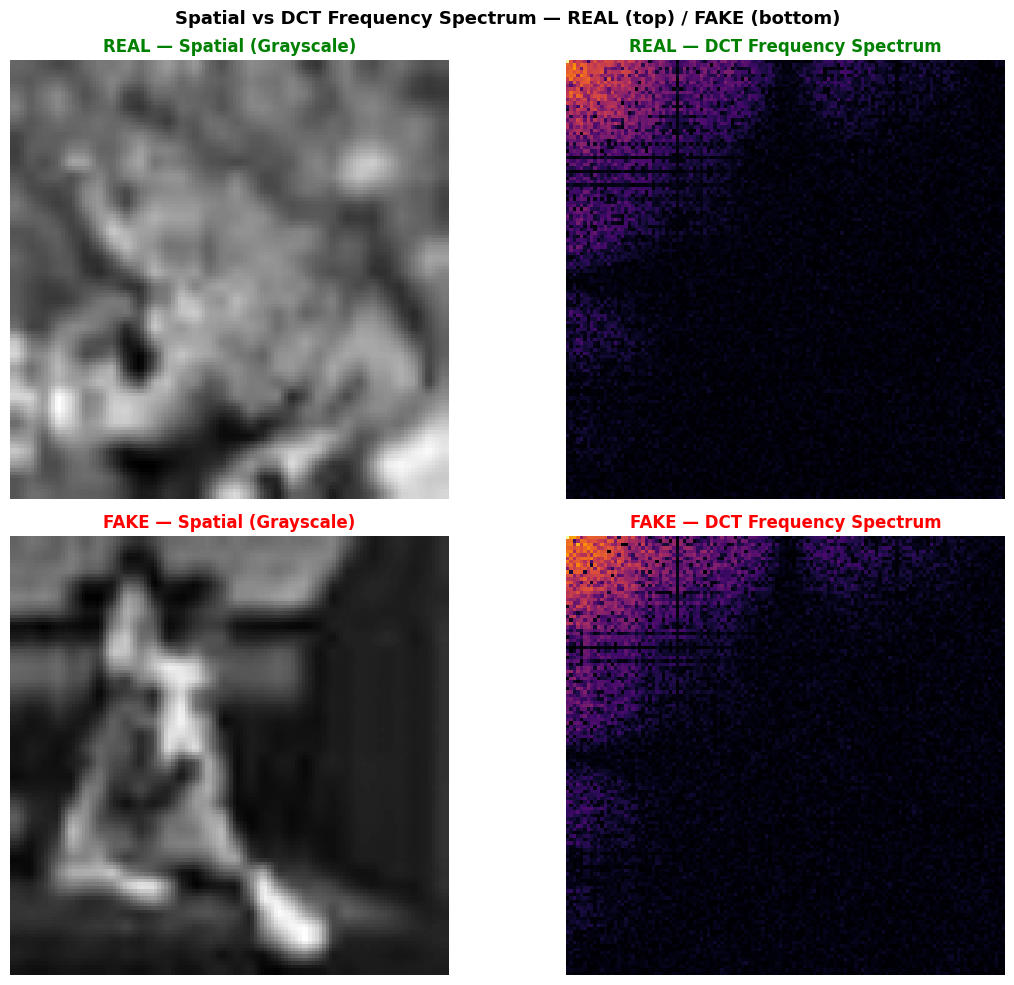

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Spatial vs DCT Frequency Spectrum — REAL (top) / FAKE (bottom)",
             fontsize=13, fontweight="bold")

axes[0, 0].imshow(real_gray, cmap="gray")
axes[0, 0].set_title("REAL — Spatial (Grayscale)", color="green", fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(real_dct_vis, cmap="inferno")
axes[0, 1].set_title("REAL — DCT Frequency Spectrum", color="green", fontweight="bold")
axes[0, 1].axis("off")

axes[1, 0].imshow(fake_gray, cmap="gray")
axes[1, 0].set_title("FAKE — Spatial (Grayscale)", color="red", fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(fake_dct_vis, cmap="inferno")
axes[1, 1].set_title("FAKE — DCT Frequency Spectrum", color="red", fontweight="bold")
axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "dct_visualization.png"), dpi=150, bbox_inches="tight")
plt.show()

---
# Phase 5 — DCT Statistical Analysis

## Define DCT Statistics Function

Three statistics are extracted per image: mean energy (average spectral intensity), standard deviation (spectral variation), and total energy (sum of squared log-coefficients). These transform visual observations into quantitative research findings.

In [6]:
def compute_dct_statistics(image_path):
    img     = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img     = cv2.resize(img, (128, 128))
    img     = np.float32(img)
    dct     = cv2.dct(img)
    dct_log = np.log(np.abs(dct) + 1)

    mean_energy  = np.mean(dct_log)
    std_freq     = np.std(dct_log)
    total_energy = np.sum(dct_log ** 2)

    return mean_energy, std_freq, total_energy

## Compute Statistics Across 100 Images Per Class

In [7]:
SAMPLE_SIZE = 100

real_means, real_stds, real_energies = [], [], []
fake_means, fake_stds, fake_energies = [], [], []

for name in os.listdir(REAL_TRAIN)[:SAMPLE_SIZE]:
    m, s, e = compute_dct_statistics(os.path.join(REAL_TRAIN, name))
    real_means.append(m); real_stds.append(s); real_energies.append(e)

for name in os.listdir(FAKE_TRAIN)[:SAMPLE_SIZE]:
    m, s, e = compute_dct_statistics(os.path.join(FAKE_TRAIN, name))
    fake_means.append(m); fake_stds.append(s); fake_energies.append(e)

print("========== REAL IMAGE DCT STATISTICS ==========")
print(f"Mean Energy   : {np.mean(real_means):.4f}")
print(f"Std Frequency : {np.mean(real_stds):.4f}")
print(f"Total Energy  : {np.mean(real_energies):.4f}")

print("\n========== FAKE IMAGE DCT STATISTICS ==========")
print(f"Mean Energy   : {np.mean(fake_means):.4f}")
print(f"Std Frequency : {np.mean(fake_stds):.4f}")
print(f"Total Energy  : {np.mean(fake_energies):.4f}")

========== REAL IMAGE DCT STATISTICS ==========
Mean Energy   : 0.5055
Std Frequency : 0.8336
Total Energy  : 15719.2236

========== FAKE IMAGE DCT STATISTICS ==========
Mean Energy   : 0.5463
Std Frequency : 0.8784
Total Energy  : 17732.6055


## Plot Distribution Comparison — REAL vs FAKE

Histograms and mean markers for all three statistics across both classes. Separation between distributions confirms that frequency-domain statistics are discriminative.

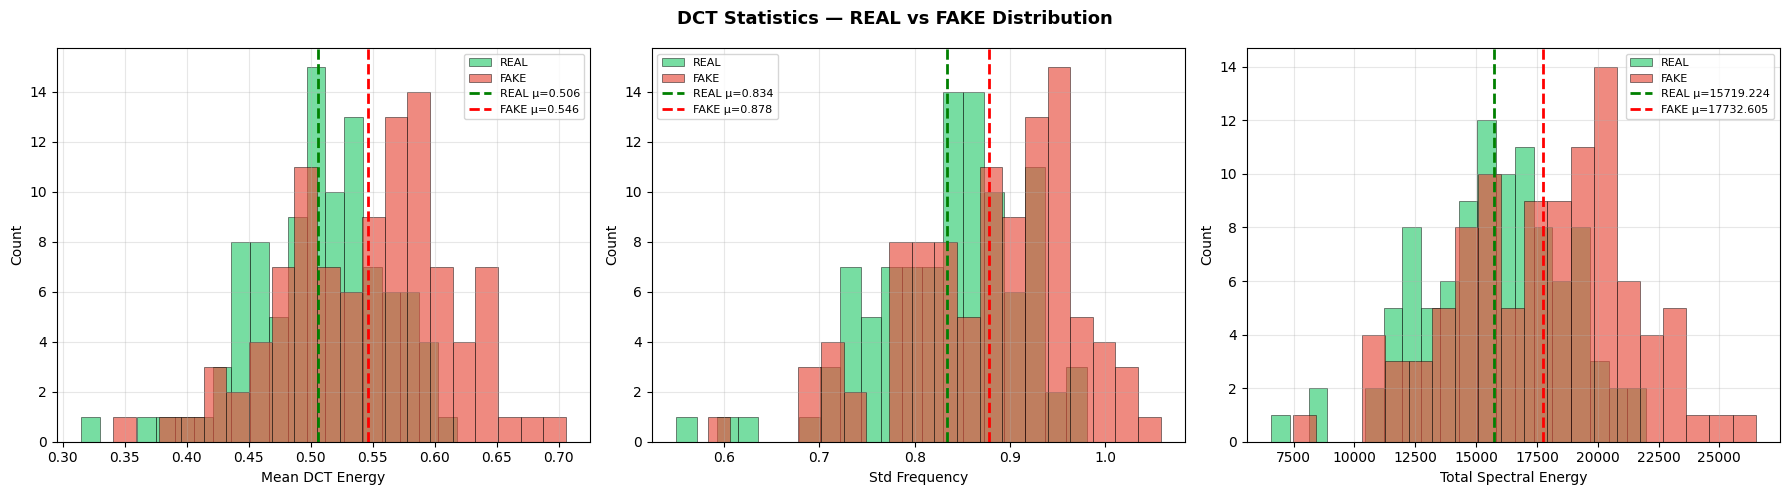

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DCT Statistics — REAL vs FAKE Distribution", fontsize=13, fontweight="bold")

plot_data = [
    (real_means,    fake_means,    "Mean DCT Energy"),
    (real_stds,     fake_stds,     "Std Frequency"),
    (real_energies, fake_energies, "Total Spectral Energy"),
]

for ax, (r_data, f_data, xlabel) in zip(axes, plot_data):
    ax.hist(r_data, bins=20, alpha=0.65, label="REAL", color="#2ecc71", edgecolor="black", linewidth=0.5)
    ax.hist(f_data, bins=20, alpha=0.65, label="FAKE", color="#e74c3c", edgecolor="black", linewidth=0.5)
    ax.axvline(np.mean(r_data), color="green", linestyle="--", linewidth=2,
               label=f"REAL μ={np.mean(r_data):.3f}")
    ax.axvline(np.mean(f_data), color="red",   linestyle="--", linewidth=2,
               label=f"FAKE μ={np.mean(f_data):.3f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "dct_statistics_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save DCT Statistics to File

In [9]:
delta_mean   = (np.mean(fake_means)    - np.mean(real_means))    / np.mean(real_means)    * 100
delta_std    = (np.mean(fake_stds)     - np.mean(real_stds))     / np.mean(real_stds)     * 100
delta_energy = (np.mean(fake_energies) - np.mean(real_energies)) / np.mean(real_energies) * 100

stats_text = f"""========== REAL IMAGE DCT STATISTICS ==========

Mean Energy   : {np.mean(real_means):.4f}
Std Frequency : {np.mean(real_stds):.4f}
Total Energy  : {np.mean(real_energies):.4f}

========== FAKE IMAGE DCT STATISTICS ==========

Mean Energy   : {np.mean(fake_means):.4f}
Std Frequency : {np.mean(fake_stds):.4f}
Total Energy  : {np.mean(fake_energies):.4f}

========== DELTA (FAKE vs REAL) ==========

Mean Energy   : +{delta_mean:.1f}%
Std Frequency : +{delta_std:.1f}%
Total Energy  : +{delta_energy:.1f}%

Interpretation:
AI-generated images exhibit elevated spectral energy and greater
frequency variation. This reflects synthetic generation artifacts
that are imperceptible spatially but measurable in frequency space.
This constitutes quantitative evidence for frequency-domain learning.
"""

with open(os.path.join(RESULT_DIR, "dct_statistics.txt"), "w") as f:
    f.write(stats_text)

print(stats_text)

========== REAL IMAGE DCT STATISTICS ==========

Mean Energy   : 0.5055
Std Frequency : 0.8336
Total Energy  : 15719.2236

========== FAKE IMAGE DCT STATISTICS ==========

Mean Energy   : 0.5463
Std Frequency : 0.8784
Total Energy  : 17732.6055

========== DELTA (FAKE vs REAL) ==========

Mean Energy   : +8.1%
Std Frequency : +5.4%
Total Energy  : +12.8%

Interpretation:
AI-generated images exhibit elevated spectral energy and greater
frequency variation. This reflects synthetic generation artifacts
that are imperceptible spatially but measurable in frequency space.
This constitutes quantitative evidence for frequency-domain learning.



---
## Phase 4 & 5 Complete

| Statistic | REAL | FAKE | Δ |
|---|---|---|---|
| Mean Energy | 0.5055 | 0.5463 | +8.1% |
| Std Frequency | 0.8336 | 0.8784 | +5.4% |
| Total Energy | 15719 | 17732 | +12.8% |

**Key Finding:** Fake images carry consistently higher frequency energy across all three statistics. This is direct quantitative evidence that a CNN trained on DCT inputs can learn these differences.

**Next → Phase 6 & 7: DCT Dataset Pipeline & Frequency CNN Training**

## Download Phase 4 & 5 Outputs

Run this cell after both phases are complete.

In [10]:
import shutil, os

OUTPUT_FILES = [
    "/kaggle/working/results/frequency_analysis/dct_visualization.png",
    "/kaggle/working/results/frequency_analysis/dct_statistics_distributions.png",
    "/kaggle/working/results/frequency_analysis/dct_statistics.txt",
]

shutil.make_archive("/kaggle/working/phase_04_05_outputs", "zip", "/kaggle/working/results/frequency_analysis")

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / 1024, 1) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<45} {size} KB")

print()
print("Download: /kaggle/working/phase_04_05_outputs.zip")

Files packaged:
  OK       dct_visualization.png                         204.3 KB
  OK       dct_statistics_distributions.png              84.4 KB
  OK       dct_statistics.txt                            0.6 KB

Download: /kaggle/working/phase_04_05_outputs.zip
